# Model 2 — Transfer Learning (ResNet18, PyTorch)
### Fire / Smoke / Non-Fire Image Classification
**CSC60904 Deep Learning — Group Assignment (Member 3 deliverable)**

This notebook builds and trains the **advanced model (Model 2)** using transfer learning in **PyTorch**, to match Member 1's data pipeline (which is PyTorch + torchvision). It plugs directly into the same dataset splits and DataLoaders your group leader set up.

**Optimization / regularization techniques used** (assignment needs ≥ 2 — this has several):
1. Transfer learning from a pretrained ImageNet backbone (ResNet18)
2. Data augmentation (from Member 1's train transforms)
3. Dropout (in the custom head)
4. Early stopping (best-val-accuracy checkpointing + patience)
5. Learning-rate scheduling (ReduceLROnPlateau)
6. Weight decay / L2 regularization (in the optimizer)



## 0. Setup & GPU check

In [1]:
import os, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Device:", device, "-", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "NO GPU — Runtime > Change runtime type > T4 GPU")

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)

PyTorch: 2.11.0+cu128
Device: cuda - Tesla T4


## 1. Get the data (same as Member 1)

This reuses Member 1's exact approach: download with `kagglehub` (no token needed) and
build the **same 70/15/15 splits** with `random_state=42` so your Model 2 trains on
identical data to Member 2's Model 1. That keeps the comparison valid.

> **If your group leader already shared the processed `data/processed` folder** (via Google
> Drive), you can skip the download: mount Drive, set `PROCESSED_DIR` to their folder, and
> jump to section 2.

In [2]:
import kagglehub

VALID_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')
PROCESSED_DIR = Path("./data/processed")

if not (PROCESSED_DIR / "train").exists():
    raw_dataset_path = kagglehub.dataset_download(
        "amerzishminha/forest-fire-smoke-and-non-fire-image-dataset")
    print("Downloaded to:", raw_dataset_path)

    # Collect valid (non-corrupted) image paths — mirrors Member 1's cleaning step.
    from PIL import Image
    valid_image_paths = []
    for root, _, files in os.walk(raw_dataset_path):
        for file in files:
            if file.lower().endswith(VALID_EXTENSIONS):
                fp = os.path.join(root, file)
                try:
                    with Image.open(fp) as im:
                        im.verify()
                    valid_image_paths.append(fp)
                except Exception:
                    pass
    print("Valid images:", len(valid_image_paths))

    # Same 70/15/15 split, same random_state as Member 1.
    train_paths, temp_paths = train_test_split(valid_image_paths, test_size=0.30, random_state=42)
    val_paths, test_paths   = train_test_split(temp_paths, test_size=0.50, random_state=42)

    import shutil
    def copy_split(paths, split):
        for p in paths:
            dest = PROCESSED_DIR / split / Path(p).parent.name
            dest.mkdir(parents=True, exist_ok=True)
            shutil.copy(p, dest / Path(p).name)
    copy_split(train_paths, "train")
    copy_split(val_paths, "val")
    copy_split(test_paths, "test")
    print(f"Split -> train {len(train_paths)} | val {len(val_paths)} | test {len(test_paths)}")
else:
    print("Found existing splits at", PROCESSED_DIR)

100%|██████████| 6.43G/6.43G [05:05<00:00, 22.6MB/s]

Extracting files...


Downloaded to: /root/.cache/kagglehub/datasets/amerzishminha/forest-fire-smoke-and-non-fire-image-dataset/versions/3
Valid images: 41152
Split -> train 28806 | val 6173 | test 6173


## 2. Preprocessing & DataLoaders (identical to Member 1)

Same image size (224), batch size (32), ImageNet normalization, and train-time
augmentation as Member 1's notebook — so nothing about the data differs between the two
models.

In [3]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 64
NORM_MEAN  = [0.485, 0.456, 0.406]
NORM_STD   = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
eval_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

train_dataset = datasets.ImageFolder(str(PROCESSED_DIR / "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(str(PROCESSED_DIR / "val"),   transform=eval_transforms)
test_dataset  = datasets.ImageFolder(str(PROCESSED_DIR / "test"),  transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes
num_classes = len(class_names)
print("Classes:", class_names)
print(f"Batches -> train {len(train_loader)} | val {len(val_loader)} | test {len(test_loader)}")

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)
with open("results/model2_class_names.json", "w") as f:
    json.dump(class_names, f, indent=2)

Classes: ['Smoke', 'fire', 'non fire']
Batches -> train 405 | val 95 | test 95


## 3. Build Model 2 — pretrained ResNet18 + custom head

ResNet18 pretrained on ImageNet. We replace its final layer with a small **Dropout +
Linear** head. Training is done in two phases: first the head only (backbone frozen),
then fine-tuning the whole network at a low learning rate.

*ResNet18 is a good pick here: small enough to train fast on Colab and to run on modest
hardware later — which strengthens the "deployable in Nepal" argument in your Deployment
section.*

In [4]:
def build_model(num_classes, freeze_backbone=True):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.parameters():
            p.requires_grad = False
    # Replace the classifier head with Dropout + Linear (regularization).
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(256, num_classes),
    )
    return model.to(device)

model = build_model(num_classes, freeze_backbone=True)
criterion = nn.CrossEntropyLoss()
print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 67.4MB/s]


Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=512, out_features=256, bias=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=256, out_features=3, bias=True)
)


## 4. Training + evaluation helpers

`train_model` runs one phase, tracks train/val loss & accuracy each epoch, applies
**early stopping** (keeps the best val-accuracy weights), and steps a
**ReduceLROnPlateau** scheduler.

In [5]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total, correct, running_loss = 0, 0, 0.0
    with torch.set_grad_enabled(training):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            if training:
                loss.backward(); optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total

def train_model(model, optimizer, scheduler, epochs, patience, history, ckpt="models/best_model2.pt"):
    best_val_acc, epochs_no_improve = 0.0, 0
    best_weights = copy.deepcopy(model.state_dict())
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, criterion)
        scheduler.step(va_loss)
        history["loss"].append(tr_loss);     history["val_loss"].append(va_loss)
        history["accuracy"].append(tr_acc);  history["val_accuracy"].append(va_acc)
        lr = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:2d}/{epochs} | lr {lr:.1e} | "
              f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
              f"val loss {va_loss:.4f} acc {va_acc:.4f}")
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, ckpt)
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping at epoch {epoch} (best val acc {best_val_acc:.4f})")
                break
    model.load_state_dict(best_weights)   # restore best
    return model

## 5. Phase 1 — train the head (backbone frozen)

Only the new head learns. `weight_decay` adds L2 regularization. Adam optimizer.

In [7]:
history = {"loss": [], "val_loss": [], "accuracy": [], "val_accuracy": []}

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2)

print("=== PHASE 1: head only ===")
model = train_model(model, optimizer, scheduler, epochs=5, patience=2, history=history)
phase1_len = len(history["loss"])

=== PHASE 1: head only ===
Epoch  1/5 | lr 1.0e-03 | train loss 0.1758 acc 0.9366 | val loss 0.0981 acc 0.9698
Epoch  2/5 | lr 1.0e-03 | train loss 0.1622 acc 0.9413 | val loss 0.0912 acc 0.9713
Epoch  3/5 | lr 1.0e-03 | train loss 0.1630 acc 0.9426 | val loss 0.0919 acc 0.9756
Epoch  4/5 | lr 1.0e-03 | train loss 0.1575 acc 0.9452 | val loss 0.0868 acc 0.9741
Epoch  5/5 | lr 1.0e-03 | train loss 0.1460 acc 0.9491 | val loss 0.0775 acc 0.9758


## 6. Phase 2 — fine-tune the whole network (low LR)

Unfreeze the backbone and continue at a much smaller learning rate so the pretrained
features adapt to fire/smoke without being destroyed.

In [9]:
for p in model.parameters():
    p.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2)

print("=== PHASE 2: fine-tuning full network ===")
model = train_model(model, optimizer, scheduler, epochs=5, patience=2, history=history)

=== PHASE 2: fine-tuning full network ===
Epoch  1/5 | lr 1.0e-05 | train loss 0.1012 acc 0.9665 | val loss 0.0538 acc 0.9822
Epoch  2/5 | lr 1.0e-05 | train loss 0.0709 acc 0.9766 | val loss 0.0447 acc 0.9834
Epoch  3/5 | lr 1.0e-05 | train loss 0.0554 acc 0.9820 | val loss 0.0416 acc 0.9847
Epoch  4/5 | lr 1.0e-05 | train loss 0.0484 acc 0.9839 | val loss 0.0371 acc 0.9862
Epoch  5/5 | lr 1.0e-05 | train loss 0.0401 acc 0.9857 | val loss 0.0339 acc 0.9880


## 7. Evaluate on the test set

In [10]:
test_loss, test_acc = run_epoch(model, test_loader, criterion)
print(f"Model 2 test accuracy: {test_acc:.4f} | test loss: {test_loss:.4f}")

Model 2 test accuracy: 0.9869 | test loss: 0.0448


## 8. Save history + training curves



Saved results/model2_history.csv


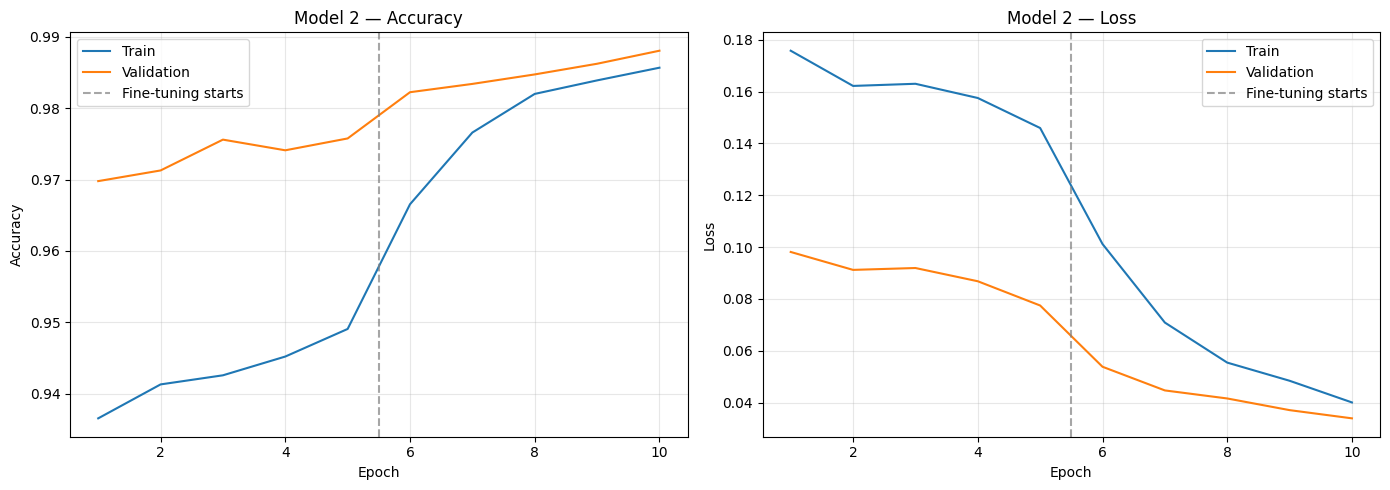

Saved results/model2_training_curves.png


In [11]:
import csv
epochs_axis = list(range(1, len(history["loss"]) + 1))
with open("results/model2_history.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["epoch", "phase", "loss", "val_loss", "accuracy", "val_accuracy"])
    for i in range(len(epochs_axis)):
        phase = "head" if i < phase1_len else "finetune"
        w.writerow([epochs_axis[i], phase, history["loss"][i], history["val_loss"][i],
                    history["accuracy"][i], history["val_accuracy"][i]])
print("Saved results/model2_history.csv")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_axis, history["accuracy"], label="Train")
ax1.plot(epochs_axis, history["val_accuracy"], label="Validation")
ax1.axvline(phase1_len + 0.5, color="gray", ls="--", alpha=0.7, label="Fine-tuning starts")
ax1.set_title("Model 2 — Accuracy"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(alpha=0.3)
ax2.plot(epochs_axis, history["loss"], label="Train")
ax2.plot(epochs_axis, history["val_loss"], label="Validation")
ax2.axvline(phase1_len + 0.5, color="gray", ls="--", alpha=0.7, label="Fine-tuning starts")
ax2.set_title("Model 2 — Loss"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/model2_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results/model2_training_curves.png")

## 9. Save your outputs


In [12]:
from google.colab import files
files.download("models/best_model2.pt")
files.download("results/model2_training_curves.png")
files.download("results/model2_history.csv")
files.download("results/model2_class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>